# **Day 2: Environment Setup and a Reproducible ML Workflow**
*Module 1 - Foundations and Tools*

A professional ML project must be **reproducible**: anyone (including us in 6 months, or a journal reviewer) should be able to re-run our code and get the **same numbers**. Reproducibility starts on Day 2, not on the day we submit a paper.

> Before learning ML we prepare a clean, repeatable workspace: one Python environment with fixed package versions, a tidy folder structure, and fixed random seeds. Then the same code gives the same result today, next month and on a colleague's computer.
>
> *Example:* If our accuracy is 0.91 today and 0.87 after a package update, we cannot tell whether the model or the software changed. A pinned environment and a fixed seed remove that doubt.

## **1. Installing the ML Stack**
Run these commands in a terminal (Anaconda Prompt on Windows), **not** in this notebook:

```bash
# create an isolated environment for this course
conda create -n ml100 python=3.12 -y
conda activate ml100

# core scientific + ML stack
pip install numpy pandas scipy scikit-learn matplotlib seaborn statsmodels
pip install xgboost lightgbm catboost shap optuna imbalanced-learn umap-learn
# deep learning (CPU build; see pytorch.org for the CUDA command matching the GPU)
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
# geospatial (Module 13)
pip install rasterio geopandas xarray earthengine-api geemap
# notebooks
pip install jupyterlab ipykernel
python -m ipykernel install --user --name ml100
```

**Google Colab:** most packages are pre-installed. Use `!pip install package` in a cell for the missing ones, and *Runtime > Change runtime type > GPU* for deep learning.

**Rule:** one environment per project. Never install everything into `base`.

## **2. Checking Versions and Hardware**

In [1]:
import sys, platform, importlib

print("Python  :", sys.version.split()[0])
print("System  :", platform.system(), platform.release(), "|", platform.machine())

packages = ["numpy", "pandas", "scipy", "sklearn", "matplotlib", "seaborn", "statsmodels",
            "xgboost", "lightgbm", "catboost", "shap", "optuna", "torch", "rasterio", "geopandas"]
versions = {}
for name in packages:
    try:
        versions[name] = importlib.import_module(name).__version__
    except ImportError:
        versions[name] = "NOT INSTALLED"
for k, v in versions.items():
    print(f"  {k:<12}{v}")

Python  : 3.12.14
System  : Windows 11 | AMD64


  numpy       2.5.3
  pandas      3.0.6
  scipy       1.18.1
  sklearn     1.9.1
  matplotlib  3.11.2
  seaborn     0.13.2
  statsmodels 0.15.0
  xgboost     3.4.1
  lightgbm    4.7.0
  catboost    1.2.10
  shap        0.52.0
  optuna      5.0.0
  torch       2.14.1+cpu
  rasterio    1.5.2
  geopandas   1.2.0


In [2]:
import os
print("CPU cores:", os.cpu_count())
try:
    import torch
    print("PyTorch CUDA GPU available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    print("Apple MPS available:", getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available())
except ImportError:
    print("PyTorch not installed (needed from Day 59)")

CPU cores: 20
PyTorch CUDA GPU available: False
Apple MPS available: False


## **3. Randomness and Seeds**
Many ML steps are random: splitting data, initialising weights, bootstrapping in Random Forests, shuffling mini-batches. Without a fixed **seed**, every run gives slightly different results.

In [3]:
import numpy as np

print("No seed  :", np.random.default_rng().integers(0, 100, 5), np.random.default_rng().integers(0, 100, 5))
print("Seed = 42:", np.random.default_rng(42).integers(0, 100, 5), np.random.default_rng(42).integers(0, 100, 5))

No seed  : [63  9 75 61 85] [77 58 58 73 31]
Seed = 42: [ 8 77 65 43 43] [ 8 77 65 43 43]


Use the modern **Generator** API (`np.random.default_rng(seed)`) instead of the old global `np.random.seed`. In scikit-learn, pass `random_state=` to every random object.

A single helper that fixes all seeds at the top of a notebook:

In [4]:
import random

def set_seed(seed: int = 42):
    """Fix the seeds of Python, NumPy and (if installed) PyTorch."""
    random.seed(seed)
    np.random.seed(seed)                      # legacy global state, used by some libraries
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass
    return np.random.default_rng(seed)

rng = set_seed(42)
print(rng.normal(size=3))

[ 0.30471708 -1.03998411  0.7504512 ]


### Seeds change results, so report the variability
A single seed hides how much the result depends on luck. Researchers run several seeds and report **mean +/- standard deviation**.

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=600, n_features=20, n_informative=6, random_state=0)
scores = []
for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=seed)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed).fit(X_tr, y_tr)
    scores.append(rf.score(X_te, y_te))
print("Accuracy per seed:", np.round(scores, 3))
print(f"Report: {np.mean(scores):.3f} +/- {np.std(scores):.3f}  (10 random splits)")

Accuracy per seed: [0.867 0.867 0.844 0.894 0.828 0.783 0.872 0.861 0.867 0.839]
Report: 0.852 +/- 0.029  (10 random splits)


The spread (often 1-3 percentage points) is larger than many "improvements" claimed in papers. Day 42 shows how to compare models statistically.

## **4. A Clean Project Structure**
Organise every project the same way. The script below creates the skeleton that we will also use for the publication projects (Day 99).

In [6]:
from pathlib import Path

project = Path("my_ml_project")
folders = ["data/raw", "data/processed", "notebooks", "src", "models", "results/figures", "results/tables"]
for f in folders:
    (project / f).mkdir(parents=True, exist_ok=True)
(project / "README.md").write_text("# My ML project\n\nQuestion, data sources, how to reproduce.\n")
(project / "requirements.txt").write_text("\n".join(f"{k}=={v}" for k, v in versions.items() if v != "NOT INSTALLED") + "\n")

for p in sorted(project.rglob("*")):
    print("   " * (len(p.relative_to(project).parts) - 1) + p.name + ("/" if p.is_dir() else ""))

data/
   processed/
   raw/
models/
notebooks/
README.md
requirements.txt
results/
   figures/
   tables/
src/


| Folder | Content | Rule |
|---|---|---|
| `data/raw` | Original data | **Never edit by hand**; read-only |
| `data/processed` | Cleaned tables, features | Created only by code |
| `src` | Reusable functions | Imported by notebooks |
| `models` | Saved trained models | Include version / date in name |
| `results` | Figures and tables for the paper | Generated by code |
| `requirements.txt` | Exact package versions | Lets others rebuild our environment |

## **5. Saving and Loading Data and Models**

In [7]:
import pandas as pd
import joblib

df = pd.DataFrame(X[:, :4], columns=["f1", "f2", "f3", "f4"]).assign(label=y)
df.to_csv(project / "data/processed/train.csv", index=False)          # human-readable
df.to_parquet(project / "data/processed/train.parquet", index=False)  # fast, typed, compressed

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(df[["f1", "f2", "f3", "f4"]], df.label)
joblib.dump(rf, project / "models/rf_v1.joblib")
rf_loaded = joblib.load(project / "models/rf_v1.joblib")
print("Same predictions after reload:", (rf_loaded.predict(df.iloc[:, :4]) == rf.predict(df.iloc[:, :4])).all())
for f in ["data/processed/train.csv", "data/processed/train.parquet", "models/rf_v1.joblib"]:
    print(f"  {f:<32}{(project / f).stat().st_size / 1024:8.1f} KB")

Same predictions after reload: True
  data/processed/train.csv            47.3 KB
  data/processed/train.parquet        25.0 KB
  models/rf_v1.joblib               1726.7 KB


**Security note:** `joblib`/`pickle` files can execute code when loaded. Only load model files we trust. Day 82 covers safer formats (ONNX).

## **Part 2: Going Deeper - Sources of Non-Reproducibility**

Even with seeds, results can differ because of:
1. **Different package versions** (an algorithm default changed). Fix with `requirements.txt` / `environment.yml`.
2. **Parallel computation**: the order of floating-point additions changes, so the sums change slightly.
3. **GPU non-determinism**: some CUDA kernels are non-deterministic (`torch.use_deterministic_algorithms(True)`).
4. **Data changes**: someone updated the raw file. Fix with checksums (below) or data versioning (Day 81).

In [8]:
import hashlib

def file_checksum(path, algo="sha256"):
    h = hashlib.new(algo)
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

print("SHA-256 of train.csv:", file_checksum(project / "data/processed/train.csv")[:16], "...")
print("Store this in our README: if the data changes, the checksum changes.")

SHA-256 of train.csv: 9ca103529e85ebe0 ...
Store this in our README: if the data changes, the checksum changes.


Floating-point arithmetic is not associative. This is why parallel sums can differ in the last digits:

In [9]:
a = np.float32(1e8); b = np.float32(-1e8); c = np.float32(1.0)
print("(a + b) + c =", (a + b) + c)
print("a + (b + c) =", a + (b + c))

(a + b) + c = 1.0
a + (b + c) = 0.0


## **Practice Problems**
1. Write an `environment.yml` file for conda with Python 3.12, numpy and scikit-learn.
2. Run the Random Forest experiment with 30 seeds and plot a histogram of the accuracies.
3. Why should `data/raw` never be edited by hand?

In [10]:
# Solution 1
yml = """name: ml100
channels: [conda-forge]
dependencies:
  - python=3.12
  - numpy
  - scikit-learn
"""
(project / "environment.yml").write_text(yml)
print((project / "environment.yml").read_text())

name: ml100
channels: [conda-forge]
dependencies:
  - python=3.12
  - numpy
  - scikit-learn



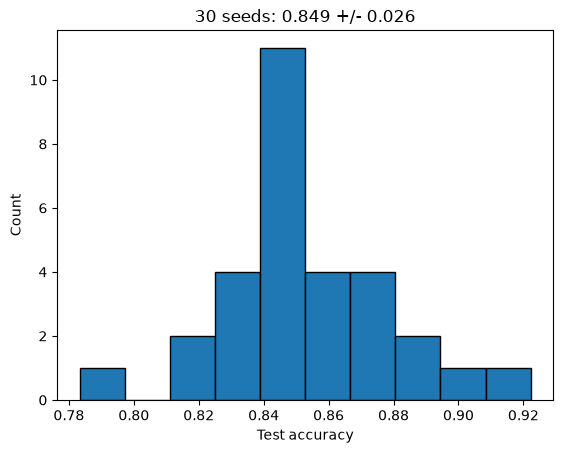

In [11]:
# Solution 2
import matplotlib.pyplot as plt
accs = []
for seed in range(30):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=seed)
    accs.append(RandomForestClassifier(n_estimators=100, random_state=seed).fit(X_tr, y_tr).score(X_te, y_te))
plt.hist(accs, bins=10, edgecolor="k"); plt.xlabel("Test accuracy"); plt.ylabel("Count")
plt.title(f"30 seeds: {np.mean(accs):.3f} +/- {np.std(accs):.3f}"); plt.show()

**Solution 3:** hand edits are invisible and cannot be repeated. Every change must be done by code, so it is documented and reproducible.

## **Key References**
- Pineau, J. et al. (2021). Improving reproducibility in machine learning research. *Journal of Machine Learning Research*, 22(164), 1-20.
- Wilson, G. et al. (2017). Good enough practices in scientific computing. *PLOS Computational Biology*, 13(6), e1005510.
- Bouthillier, X., Laurent, C., & Vincent, P. (2019). Unreproducible research is reproducible. *ICML 2019*.